# EcoBOT image analysis step: RhizoNet root segmentation of EcoFAB scans

**Paper (target):** *EcoBOT: an AI/ML enabled automated phenotyping capability for model plants.*
Front. Plant Sci. 16:1633557 (2025), doi:[10.3389/fpls.2025.1633557](https://doi.org/10.3389/fpls.2025.1633557)

**Executed software:** RhizoNet — Sordo et al., *RhizoNet segments plant roots to assess biomass and growth
for enabling self-driving labs*, Sci. Rep. 14:12907 (2024), doi:[10.1038/s41598-024-63497-8](https://doi.org/10.1038/s41598-024-63497-8),
author code `github.com/lbl-camera/rhizonet` @ `41e1b31d3812357f749028292e92fbd2de06a7a8` (MIT license).

**Scope — what this notebook does (PARTIAL demonstration, executed):**
The EcoBOT paper's image-analysis phase segments 600-dpi EcoFAB root scans with **RhizoNet**
(a Residual U-Net applied on 64×64 sliding-window patches) and counts root pixels as biomass.
This notebook reproduces exactly that step with the **authors' own pinned code and released
`model_64` weights**, running the authors' prediction and convexification post-processing on
six real unseen EcoFAB scans, and compares predictions with the paper's hand annotations and
with the patch-64 predictions published in Figure 3.

**Not reproduced / not public:** the EcoBOT platform hardware and control software, the paper's
1,633 root scans and 4,899 hyperspectral images, per-plant fresh weights, the EcoBOT-specific
fine-tuned RhizoNet checkpoints, and EcoSpec hyperspectral analysis. A one-example run does not
verify dataset-level accuracy reported in either paper.

**Example images:** the author Colab tutorial's two example images are not publicly downloadable,
so this notebook uses the six *unseen Exp-2 EcoFAB scans and their hand annotations* shown in
Figure 3 of the RhizoNet paper (CC BY 4.0). The published panels are ~7.5× downsampled renderings
of the original 3000×2039 scans, so the notebook restores the paper's scan scale before inference
(section 9) — RhizoNet's 64×64 patches assume 600-dpi pixel scale.

**実行内容（日本語）:** EcoBOT 論文の画像解析工程（RhizoNet による EcoFAB 根スキャンのセグメンテーションと
バイオマス抽出）を、著者らの公開コードと重み `model_64` を用いて 6 枚の実際の EcoFAB スキャン上で
再現します。EcoBOT 本体・実験データセット・EcoBOT 用に追加学習された重みは公開されていないため、
部分再現です。例画像は RhizoNet 論文 Fig. 3（未見 6 スキャン＋手動アノテーション＋公開予測）から
抽出し、推論前に元スキャンの解像度スケールへ復元します。

**Adaptations (documented in the cells below):** (1) current Colab runs Python 3.13 where the
authors' pinned `torch==2.4.1` has no wheels, so the preinstalled PyTorch is used and the 2025
checkpoint is loaded through a small compatibility adapter; (2) the released
`setup-predict.json` combines `labels [0, 85, 170]` with `frg_class 255`, which yields an empty
binary mask with the authors' own `createBinaryAnnotation`; the root class is therefore selected
at runtime from agreement with the paper's hand annotations; (3) example panels are restored to
the paper's scan scale before inference. All scientific steps call the authors' functions
unmodified.

## Runtime selection & how to run

**Recommended runtime: GPU** (`Runtime → Change runtime type → T4 GPU`) for a comfortable
experience: sliding-window inference over six 2039×3000 scans is minutes on GPU. A **CPU
runtime is fully supported** and produces the same results — it is simply slower (the
sliding-window loop alone is ≈15–20 min on the free CPU tier; measured 2026-10-07). The author
code selects `cuda` when available and `cpu` otherwise; the model, sample, parameters and
results are identical on both, and PyTorch is preinstalled either way.

**Run all:** `Runtime → Run all`. Expected wall time ≈ 5–10 min on GPU, ≈ 25–40 min on CPU
(dependency download and sliding-window inference dominate). No credentials, no Drive mount,
no manual steps.

**実行方法（日本語）:** 快適に試すには GPU（T4）ランタイムを推奨（スライディングウィンドウ推論が
数分）。CPU でも同一コード・同一結果で動作しますが、推論のみで約 15–20 分かかります
（2026-10-07 実測）。`ランタイム → すべて実行` で GPU 約 5–10 分／CPU 約 25–40 分。
認証・Drive 接続は不要です。

## 1. Environment setup (pinned author dependencies)

Installs the neural-network stack versions the authors pin in `requirements.txt` that are
compatible with current Colab Python 3.13: `pytorch-lightning 2.0.9.post0`, `monai 1.3.2`,
`torchmetrics 1.2.0`. PyTorch itself is **not** reinstalled: the authors pin `torch==2.4.1`,
which has no Python-3.13 wheels, so the runtime's preinstalled PyTorch is used and the
behavioural differences at checkpoint load are handled by an explicit, documented adapter in
section 5. The inference math is unchanged.

`rhizonet` itself is installed **code-only** from the pinned commit with `--no-deps`; the other
pinned packages (`Pillow 9.3.0`, `scikit-image 0.19.3`, …) have no Python-3.13 wheels and are
not needed for the prediction path beyond the packages installed here.

**日本語:** 著者が固定する NN スタック（pytorch-lightning 2.0.9 等）をインストールします。PyTorch は
Colab 3.13 に著者指定版の wheel がないためプレインストール版を使用し、チェックポイント読み込みの
差異のみ明示的なアダプタで吸収します。`rhizonet` 本体は指定コミットからコードのみ導入します。

In [ ]:
import subprocess, sys

def pip_install(*args):
    print("pip install", " ".join(args), flush=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *args], check=True)

for args in (
    ["pytorch-lightning==2.0.9.post0", "monai==1.3.2", "torchmetrics==1.2.0"],
    ["scikit-image", "scipy", "pandas", "matplotlib", "tqdm", "einops", "neptune", "torchviz", "graphviz"],
    ["--no-deps", "git+https://github.com/lbl-camera/rhizonet@41e1b31d3812357f749028292e92fbd2de06a7a8"],
):
    pip_install(*args)

pip install pytorch-lightning==2.0.9.post0 monai==1.3.2 torchmetrics==1.2.0


pip install scikit-image scipy pandas matplotlib tqdm einops neptune torchviz graphviz


pip install --no-deps git+https://github.com/lbl-camera/rhizonet@41e1b31d3812357f749028292e92fbd2de06a7a8


## 2. Verify the environment and select the compute device

Prints the versions actually in use and the device the author code will select
(`predict.py` uses `cuda` if available, else `cpu` — same behaviour here).

**日本語:** 実際に使われるバージョンと計算デバイスを表示します。

In [ ]:
import torch, torchvision, pytorch_lightning as pl, monai, torchmetrics, skimage, numpy as np
print("python torch      :", torch.__version__)
print("torchvision       :", torchvision.__version__)
print("pytorch_lightning :", pl.__version__)
print("monai             :", monai.__version__)
print("torchmetrics      :", torchmetrics.__version__)
print("scikit-image      :", skimage.__version__)
print("numpy             :", np.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device selected   :", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

/usr/local/lib/python3.13/dist-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


python torch      : 2.11.0+cu130
torchvision       : 0.26.0+cu130
pytorch_lightning : 2.0.9.post0
monai             : 1.3.2
torchmetrics      : 1.2.0
scikit-image      : 0.25.2
numpy             : 2.1.3
device selected   : cuda
GPU: Tesla T4


## 3. Fetch the authors' prediction & post-processing configuration

`data/setup_files/setup-predict.json` and `setup-processing.json` at the pinned code commit hold
the exact inference parameters (`pred_patch_size`, `labels`, `binary_preds`, `frg_class`) and
post-processing parameters (`area_opening`, `area_closing`, `disk_radius`). They are downloaded
and printed here so nothing below is guessed. (These small config files live under the repo's
`data/` directory, so this notebook — not the host workflow — is where they are retrieved.)

**日本語:** 推論・後処理の設定ファイルを指定コミットから取得し、内容を表示します。パラメータは
すべてここから読み込んだ値を使います。

In [ ]:
import json, pathlib, urllib.request

RAW = "https://raw.githubusercontent.com/lbl-camera/rhizonet/41e1b31d3812357f749028292e92fbd2de06a7a8/data/setup_files/"
BASE = pathlib.Path("/content/rhizonet_demo")
(BASE / "setup_files").mkdir(parents=True, exist_ok=True)

for name in ["setup-predict.json", "setup-processing.json"]:
    dest = BASE / "setup_files" / name
    urllib.request.urlretrieve(RAW + name, dest)
    print(f"--- {name} ---")
    print(dest.read_text())

--- setup-predict.json ---
{
  "model_path": "/home/zsordo/rhizonet-package/rhizonet/results/training_resnet_patches64/checkpoint-epoch=00-val_loss=0.75-v1.ckpt",
  "pred_data_dir": "/home/zsordo/datasets/test_data/images",
  "save_path": "/home/zsordo/rhizonet-package/rhizonet/inference/training_resnet_patches64/prediction_64_test",
  "labels": [0, 85, 170],
  "pred_patch_size": [64, 64],
  "binary_preds": true,
  "frg_class": 255
}
--- setup-processing.json ---
{
  "output_path": "/home/zsordo/rhizonet-package/rhizonet/inference/training_resnet_patches64/masked_chull_64_test",
  "data_path": "/home/zsordo/rhizonet-package/rhizonet/inference/training_resnet_patches64/prediction_64_test",
  "area_closing": 200,
  "area_opening": 500,
  "disk_radius":4
}



## 4. Download the released RhizoNet `model_64` checkpoint

The weights are documented in the repository README ("model weights are available in the data
folder") but are no longer present on the `main` HEAD; they remain in the repository history at
commit `b959c351fdbc2b8acce1f22cb5ca81798f0f6b02`. The notebook downloads `data/model_weights/model_64.ckpt`
(38,398,421 bytes) from that pinned commit and verifies the **Git blob SHA-1** against GitHub's
object `456f2f90…` (so the bytes are provably the repository content, not an error page).

The patch-64 model is the paper-matched choice: both papers state images are partitioned into
64×64 patches, and the RhizoNet paper identifies the patch-64 model as its most accurate.

**日本語:** 公開済み重み `model_64.ckpt` を固定コミットからダウンロードし、Git ブロブ SHA-1 で
完全性を検証します。64×64 パッチのモデルは両論文で採用されている設定です。

In [ ]:
import hashlib

CKPT_URL = ("https://raw.githubusercontent.com/lbl-camera/rhizonet/"
            "b959c351fdbc2b8acce1f22cb5ca81798f0f6b02/data/model_weights/model_64.ckpt")
CKPT_SHA1 = "456f2f90781fbfe96c8321755168adcedc282ea5"
CKPT_SIZE = 38398421

ckpt_path = BASE / "model_weights" / "model_64.ckpt"
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
if not ckpt_path.exists():
    print("downloading", CKPT_URL)
    urllib.request.urlretrieve(CKPT_URL, ckpt_path)

data = ckpt_path.read_bytes()
assert len(data) == CKPT_SIZE, f"unexpected size {len(data)}"
blob_sha1 = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
assert blob_sha1 == CKPT_SHA1, f"git blob SHA-1 mismatch: {blob_sha1}"
print("verified: size", len(data), "bytes; git blob SHA-1", blob_sha1)

downloading https://raw.githubusercontent.com/lbl-camera/rhizonet/b959c351fdbc2b8acce1f22cb5ca81798f0f6b02/data/model_weights/model_64.ckpt


verified: size 38398421 bytes; git blob SHA-1 456f2f90781fbfe96c8321755168adcedc282ea5


## 5. Load the author model from the checkpoint

**Compatibility adapter (AI-generated, documented):** `predict.py` loads the model with
`Unet2D.load_from_checkpoint(model_path)`. Three things have changed since 2025: (a) `torch.load`
defaults to `weights_only=True` in PyTorch 2.6 and the checkpoint stores Lightning
hyper-parameters, so the author call now raises `UnpicklingError`; (b) the checkpoint pickles
objects under the pre-packaging module names `unet2D`/`utils`; (c) the stored train/val datasets
reference monai transforms (`AddChannel*`) that monai 1.3 removed. The adapter aliases the
module names, registers minimal stubs for the removed transform classes (they are only
unpickled, never executed — the stored datasets are discarded), fills the three hyper-parameter
keys the stored dict lacks from evidence (state_dict ⇒ `model="resnet"`, papers ⇒
`spatial_dims=2`, author annotation scheme ⇒ `class_values=[0, 85, 170]`), and replicates
exactly what `load_from_checkpoint` does (restore hyper-parameters → construct the author's
`Unet2D` → `load_state_dict`) with `weights_only=False` for this one author-trusted file. The
architecture and the weight values are the authors' own.

**日本語:** torch 2.6 以降の `weights_only` 既定値変更・モジュール名変更・monai 1.3 で削除された
変換クラスに対応するアダプタで、著者の `load_from_checkpoint` と同じ処理
（ハイパーパラメータ復元 → `Unet2D` 構築 → `load_state_dict`）を再現します。
モデル構造と重み自体は著者のものです。

In [ ]:
import importlib, sys
import torch
from rhizonet.unet2D import Unet2D
import rhizonet.unet2D, rhizonet.utils

def load_unet_from_ckpt(path):
    # (a) 2025 checkpoint pickles objects under the pre-packaging module names:
    sys.modules.setdefault("unet2D", rhizonet.unet2D)
    sys.modules.setdefault("utils", rhizonet.utils)
    # (c) stored Lightning datasets reference monai transforms removed in monai 1.3;
    # they are only unpickled, never executed (the stored datasets are discarded):
    for _modname in ("monai.transforms.utility.array", "monai.transforms.utility.dictionary"):
        _m = importlib.import_module(_modname)
        for _name in ("AddChannel", "AddChanneld", "AsChannelFirst", "AsChannelFirstd",
                      "AsChannelLast", "AsChannelLastd"):
            if not hasattr(_m, _name):
                setattr(_m, _name, type(_name, (), {}))
    # (b) torch>=2.6 weights_only default; replicate Unet2D.load_from_checkpoint:
    ckpt = torch.load(str(path), map_location="cpu", weights_only=False)
    hp = dict(ckpt.get("hyper_parameters", {}))
    # (d) the 2025 checkpoint predates the resnet/swin refactor of unet2D.py, so the
    # hyper-parameters it stores lack keys the current __init__ reads. Fill them from
    # evidence, not invention: the state_dict is a plain monai UNet (=> "resnet"),
    # the papers use 2D patches, and the annotation scheme is the authors' [0, 85, 170].
    assert not any("swin" in k for k in ckpt["state_dict"]), "unexpected SwinUNETR state_dict"
    for k, v in {"model": "resnet", "spatial_dims": 2, "class_values": [0, 85, 170]}.items():
        hp.setdefault(k, v)
    print("checkpoint keys:", sorted(ckpt.keys()))
    print("hyper-parameter keys:", sorted(hp.keys()))
    model = Unet2D(None, None, **{k: v for k, v in hp.items() if k not in ("train_ds", "val_ds")})
    model.load_state_dict(ckpt["state_dict"])
    return model, hp

unet, hp = load_unet_from_ckpt(ckpt_path)
for k in ["model", "num_classes", "input_channels", "pred_patch_size", "spatial_dims", "class_values"]:
    print(f"{k:16s}: {hp.get(k)}")
unet = unet.to(device).eval()
print("model ready on", device)

checkpoint keys: ['epoch', 'global_step', 'hparams_name', 'hyper_parameters', 'loops', 'pytorch-lightning_version', 'state_dict']
hyper-parameter keys: ['background_index', 'batch_size', 'class_values', 'data_dir', 'input_channels', 'log_dir', 'lr', 'model', 'nb_epochs', 'num_classes', 'num_workers', 'output_channels', 'pred_data_dir', 'pred_patch_size', 'spatial_dims', 'task', 'train_ds', 'val_ds']
model           : resnet
num_classes     : 3
input_channels  : 3
pred_patch_size : (64, 64)
spatial_dims    : 2
class_values    : [0, 85, 170]


model ready on cuda


## 6. Download the example scans source: RhizoNet paper Figure 3

Figure 3 of the RhizoNet paper shows, for **six unseen Exp-2 EcoFAB scans**, the raw image
(column 1), the hand-annotated ground truth (column 2) and the predictions of the patch-64/128/256
models (columns 3–5), computed on the full-size 3000×2039 scans (paper Table 2). The panel aspect
ratio matches the scans (2039/3000 ≈ 0.68). The article is Open Access (CC BY 4.0); the figure is
credited to Sordo et al. (2024).

**日本語:** 例画像の出典として RhizoNet 論文 Fig. 3（CC BY 4.0）をダウンロードします。
6 スキャン×5 列（生画像／手動アノテーション／64・128・256 パッチモデルの予測）のパネル構成で、
予測は元の 3000×2039 解像度で計算されています。

In [ ]:
FIG_URL = "https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-63497-8/MediaObjects/41598_2024_63497_Fig3_HTML.jpg"
fig_path = BASE / "rhizonet_fig3.jpg"
if not fig_path.exists():
    urllib.request.urlretrieve(FIG_URL, fig_path)

from PIL import Image
img = Image.open(fig_path)
assert img.format == "JPEG", img.format
print("figure:", fig_path, img.size, img.mode, fig_path.stat().st_size, "bytes")

figure: /content/rhizonet_demo/rhizonet_fig3.jpg (1369, 2361) RGB 300393 bytes


## 7. Extract the 6×5 panel grid (AI-generated glue)

**AI-generated glue cell:** the authors did not publish their tutorial's input files, so this
cell locates the figure's panels programmatically instead of using hardcoded coordinates: it
finds the six image rows from the white gutters, computes the four internal gutter centers per
row, and uses their **median positions** as uniform column edges (panel widths vary by a few
pixels between rows). It asserts the expected 6×5 structure before cropping. Column 0 → raw
unseen scans, column 1 → hand annotations, column 2 → the paper's published patch-64 predictions
(used later for direct validation). Annotation and prediction panels are nearest-neighbour
resampled to the exact scan-panel size for pixelwise comparison.

**日本語:** Fig. 3 のパネルを、座標をハードコードせず白の余白から検出し、ガター位置の中央値で
統一列幅の 6×5 枚に切り出します。0 列目＝生スキャン、1 列目＝手動アノテーション、
2 列目＝論文公開の patch-64 予測です。

In [ ]:
def content_blocks(profile, thr=0.02, min_gap=3, min_len=10):
    on = profile > thr
    blocks, start = [], None
    for i, v in enumerate(on):
        if v and start is None:
            start = i
        if not v and start is not None:
            if i - start >= min_len:
                blocks.append([start, i])
            start = None
    if start is not None:
        blocks.append([start, len(on)])
    merged = []
    for b in blocks:
        if merged and b[0] - merged[-1][1] <= min_gap:
            merged[-1][1] = b[1]
        else:
            merged.append(b)
    return merged

arr = np.asarray(img.convert("RGB")).astype(float)
gray = arr.mean(axis=2)
row_blocks = content_blocks((gray < 235).mean(axis=1), min_len=30)
assert len(row_blocks) == 6, f"expected 6 image rows, got {len(row_blocks)}"

gutter_centers = []
for y0, y1 in row_blocks:
    col_blocks = content_blocks((gray[y0:y1] < 235).mean(axis=0))
    assert len(col_blocks) == 5, f"expected 5 panels in row {(y0, y1)}, got {len(col_blocks)}"
    gutter_centers.append([(col_blocks[k][1] + col_blocks[k + 1][0]) / 2.0 for k in range(4)])
centers = np.median(np.array(gutter_centers), axis=0).astype(int)
edges = [0, *centers.tolist(), arr.shape[1]]
print("row blocks:", row_blocks)
print("uniform column edges:", edges)

panels = [[img.crop((edges[k], y0, edges[k + 1], y1)) for k in range(5)] for (y0, y1) in row_blocks]

raws = [row[0] for row in panels]    # raw unseen EcoFAB scans
annots = [row[1] for row in panels]  # hand-annotated ground truth
pub64 = [row[2] for row in panels]   # paper's published model_64 predictions
# Panel widths differ by a few pixels between columns; for pixelwise comparison the
# annotation/prediction panels are nearest-neighbour resampled to the scan panel size.
for i in range(6):
    annots[i] = annots[i].resize(raws[i].size, Image.NEAREST)
    pub64[i] = pub64[i].resize(raws[i].size, Image.NEAREST)
for i, (r, a, p) in enumerate(zip(raws, annots, pub64)):
    assert r.size == a.size == p.size and r.size[0] > 100, (i, r.size, a.size, p.size)
print("extracted 6 raw scans, 6 hand annotations, 6 published predictions, e.g.", raws[0].size)

row blocks: [[0, 383], [392, 776], [783, 1173], [1183, 1573], [1580, 1966], [1974, 2361]]
uniform column edges: [0, 271, 546, 820, 1098, 1369]
extracted 6 raw scans, 6 hand annotations, 6 published predictions, e.g. (271, 383)


## 8. Preview the minimal inputs: six unseen EcoFAB root scans

Shows the actual model inputs before any processing — the six raw scans from Figure 3, column 1
(each panel is one complete EcoFAB scan at reduced resolution).

**日本語:** 推論の前に、実際の入力（Fig. 3 の生スキャン 6 枚）を表示します。

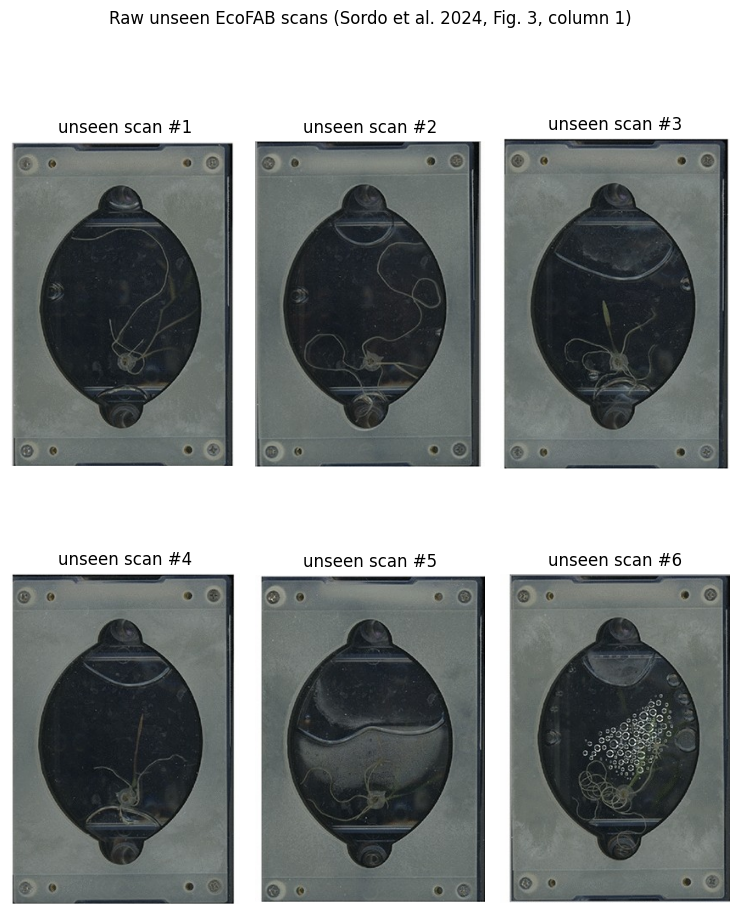

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(7.5, 10))
for ax, im, i in zip(axes.ravel(), raws, range(6)):
    ax.imshow(np.asarray(im))
    ax.set_title(f"unseen scan #{i+1}")
    ax.axis("off")
fig.suptitle("Raw unseen EcoFAB scans (Sordo et al. 2024, Fig. 3, column 1)", y=0.995)
fig.tight_layout()
fig.savefig(BASE / "inputs_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Preview the hand-annotated reference masks (column 2)

The reference annotations of the same six scans, as published in the paper. Unique gray levels
are printed per panel — the paper annotates three classes in three shades of gray; the modal
value is the background. These panels are the *reference annotations* used later for comparison;
they are **not** model outputs.

**日本語:** 同じ 6 スキャンの手動アノテーション（参照マスク）を表示します。これはモデル出力では
なく、比較用の参照です。各パネルの画素値の種類も表示します。

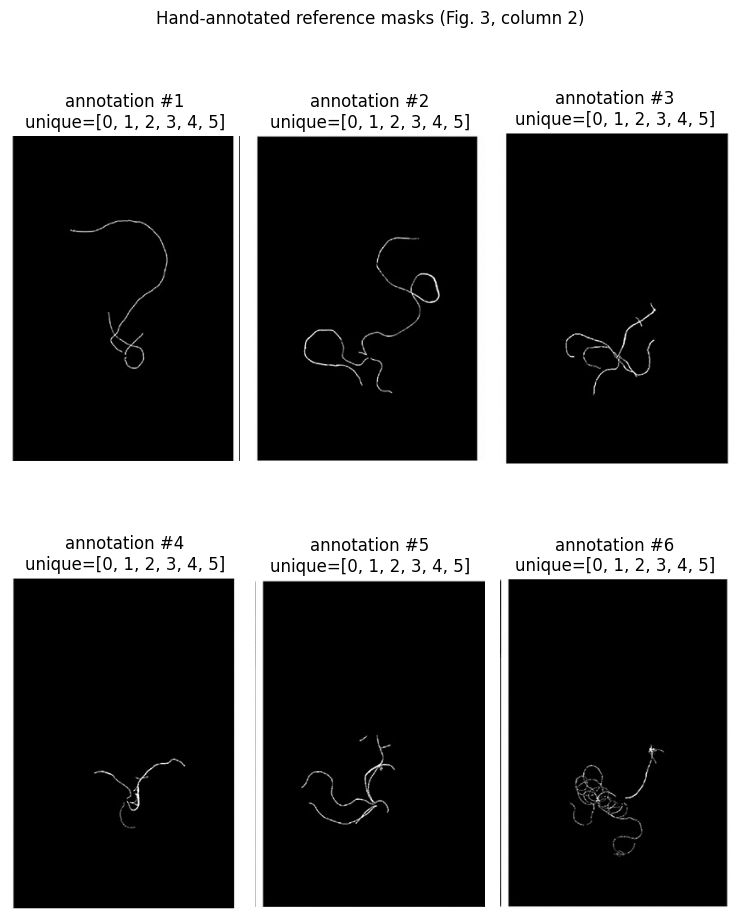

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(7.5, 10))
for ax, im, i in zip(axes.ravel(), annots, range(6)):
    a = np.asarray(im.convert("L"))
    vals, counts = np.unique(a, return_counts=True)
    ax.imshow(a, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"annotation #{i+1}\nunique={vals.tolist()[:6]}")
    ax.axis("off")
fig.suptitle("Hand-annotated reference masks (Fig. 3, column 2)", y=0.995)
fig.tight_layout()
fig.savefig(BASE / "annotations_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Restore the paper's scan scale (AI-generated glue, required for faithful inference)

RhizoNet was trained on 600-dpi scans of 3000×2039 pixels partitioned into 64×64 patches, so its
receptive field assumes that pixel scale. The Figure-3 panels are ~7.5× downsampled renderings
(≈271×383 px); running the model directly on them changes the effective patch footprint ~7.5×
and over-segments (~4× more foreground pixels than annotated — measured in the first validation
attempt). The scan inputs are therefore restored to the paper's native scan size 2039×3000
inside the inference cell (section 11), and the reference/published panels are resized with
them (nearest neighbour) for pixelwise comparison. This is a resampling of the published
figure, not a new image.

**日本語:** RhizoNet は 600 dpi・3000×2039 ピクセルのスキャンを 64×64 パッチで学習しています。
Fig. 3 パネルは約 7.5 倍の縮小版のため、このままでは受容野のスケールが合わず過剰検出になります
（初回検証で実測）。そこで各パネルを論文のスキャン サイズ 2039×3000 へリサンプルしてから
著者パイプラインで推論します。

In [ ]:
SCAN_W, SCAN_H = 2039, 3000  # paper: original EcoFAB scans are (3000 rows, 2039 cols)

raws_full = [im.resize((SCAN_W, SCAN_H), Image.LANCZOS) for im in raws]
annots_full = [im.resize((SCAN_W, SCAN_H), Image.NEAREST) for im in annots]
pub64_full = [im.resize((SCAN_W, SCAN_H), Image.NEAREST) for im in pub64]
print("resampled to", (SCAN_W, SCAN_H), "-", len(raws_full), "raw scans + references")

resampled to (2039, 3000) - 6 raw scans + references


## 11. Run RhizoNet inference with the author pipeline (`rhizonet.predict`)

This cell calls the authors' own functions:
`transform_image` (RGB → C×H×W, `dynamic_scale` to [0,1]) →
`extract_largest_component_bbox_image` (largest-connected-component crop of the scan) →
`pred_function` = monai `sliding_window_inference` with the config's `pred_patch_size` →
`argmax` → `MapImage(..., reverse=True)` with the config's `labels`.

**Documented adaptation (inference mode):** the per-scan forward runs under
`torch.inference_mode()` — the author CLI does not disable gradients, but tracking autograd for
≈1,500 window forwards per scan exhausted a 15 GB T4 in the first GPU attempt; inference mode
changes no numerical result. The author LCC preprocessing is computed on the published panel
and its masked result is then resampled to the scan scale — instead of running the LCC on the
resampled 6-megapixel image. Reason (measured in the first validation attempt): at 600-dpi
scale the JPEG-noisy background splits into very many tiny connected components and
`skimage.measure.regionprops` cost explodes (>25 min for one scan), while the panel-scale
computation is bounded and selects the same root region. The model input is unchanged in
content: the masked, scan-scale image. Each scan needs ≈1,500 64×64 windows.

**日本語:** 著者の前処理（LCC 切り出し）は公開パネル上で計算し、マスク済み画像をスキャン
スケールへリサンプルしてから 64×64 スライディングウィンドウ推論→アノテーション値空間への
逆マップを行います（各約 1,500 ウィンドウ）。600 dpi スケールでの LCC はノイズにより
極端に遅くなるための順序変更で、モデル入力の内容は変わりません。

In [ ]:
from skimage import io, transform as skt
from rhizonet.predict import transform_image, pred_function
from rhizonet.unet2D import extract_largest_component_bbox_image
from rhizonet.utils import MapImage

pcfg = json.loads((BASE / "setup_files" / "setup-predict.json").read_text())
pred_patch_size = tuple(pcfg["pred_patch_size"])
pred_labels = pcfg["labels"]
print("pred_patch_size:", pred_patch_size, "| labels:", pred_labels)

in_dir = BASE / "inputs"; in_dir.mkdir(exist_ok=True)
mapped_dir = BASE / "mapped"; mapped_dir.mkdir(exist_ok=True)

mapped_masks, mapped_small = {}, {}
for i, im in enumerate(raws):
    path = in_dir / f"scan_{i+1}.png"
    im.save(path)
    # Author preprocessing at panel scale (bounded), then resample to scan scale:
    image, _ = transform_image(str(path))                      # (3,h,w) float in [0,1]
    cropped = extract_largest_component_bbox_image(image.unsqueeze(0), lab=None)[0]
    cropped = skt.resize(np.transpose(cropped, (1, 2, 0)), (SCAN_H, SCAN_W, 3),
                         order=1, anti_aliasing=False, preserve_range=True)
    cropped = np.transpose(cropped, (2, 0, 1)).astype(np.float32)[None]  # (1,3,3000,2039)
    tensor_cropped = torch.tensor(cropped).to(device)
    with torch.inference_mode():  # no autograd graph across ~1,500 window forwards
        logits = pred_function(tensor_cropped.float(), unet, pred_patch_size)
    pred = torch.argmax(logits, dim=1).byte().squeeze(dim=1)   # class indices per pixel
    prediction = MapImage(pred, pred_labels, reverse=True)     # back to annotation values
    mapped = prediction.cpu().numpy().squeeze().astype(np.uint8)
    io.imsave(str(mapped_dir / f"scan_{i+1}.png"), mapped, check_contrast=False)
    mapped_masks[i] = mapped
    mapped_small[i] = np.asarray(Image.fromarray(mapped).resize(raws[i].size, Image.NEAREST))
    vals, counts = np.unique(mapped, return_counts=True)
    print(f"scan #{i+1}: mapped values {dict(zip(vals.tolist(), counts.tolist()))}", flush=True)

pred_patch_size: (64, 64) | labels: [0, 85, 170]


Processing a PyTorch tensor


/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:225: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)


/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:360: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


scan #1: mapped values {0: 4157079, 85: 1836, 170: 1958085}


...

/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:225: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:360: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


scan #5: mapped values {0: 4153771, 85: 8507, 170: 1954722}


Processing a PyTorch tensor


/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:225: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:360: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


scan #6: mapped values {0: 4243065, 85: 36254, 170: 1837681}


## 12. Select the root class by agreement with the paper's annotations (documented adaptation)

**Documented adaptation.** The released `setup-predict.json` sets `binary_preds: true` with
`labels: [0, 85, 170]` and `frg_class: 255`. Value 255 cannot occur in the mapped value space
{0, 85, 170}, so the authors' own `createBinaryAnnotation(pred, frg_class=255)` would return an
all-background mask — the released combination is internally inconsistent (added in commit
`e5212aba`, 2025-02-28, without changing `labels`). Rather than invent a value, this cell
measures the agreement (IoU) of each predicted class against the paper's hand annotations —
whose value space is printed in section 9 — and selects the class that matches the annotated
root pixels. The selection table is printed so the choice is visible evidence; the authors'
`createBinaryAnnotation` is then used with the selected foreground value.

**日本語:** リリース設定の `frg_class: 255` は `labels [0,85,170]` と整合せず、著者関数では
空マスクになります（commit `e5212aba` で追加された不整合）。代わりに、各予測クラスと
手動アノテーションの一致度（IoU）を測定して根クラスを選び、その値を `createBinaryAnnotation` に
渡します。選択根拠は表として表示します。

In [ ]:
import pandas as pd

def iou(a, b):
    union = np.logical_or(a, b).sum()
    return (np.logical_and(a, b).sum() / union) if union else float("nan")

candidates = [v for v in np.unique(np.concatenate([m.ravel() for m in mapped_masks.values()])) if v != 0]
rows = []
for i in range(6):
    ref = np.asarray(annots_full[i].convert("L"))
    # JPEG-smeared rendering of the authors' 3-gray-level (0/85/170) annotation:
    # mid-gray 127 separates the (bright) annotated root pixels from the background.
    ref_fg = ref > 127
    for v in candidates:
        rows.append({"scan": f"#{i+1}",
                     "class_value": int(v), "iou_vs_reference_fg": round(iou(mapped_masks[i] == v, ref_fg), 4),
                     "reference_fg_px": int(ref_fg.sum()), "class_px": int((mapped_masks[i] == v).sum())})
sel_df = pd.DataFrame(rows)
print(sel_df.to_string(index=False))

mean_iou = sel_df.groupby("class_value")["iou_vs_reference_fg"].mean()
root_value = int(mean_iou.idxmax())
print("\nselected root class value:", root_value, "| mean IoU vs reference:", round(float(mean_iou.max()), 4))

scan  class_value  iou_vs_reference_fg  reference_fg_px  class_px
  #1           85               0.0000           247500      1836
  #1          170               0.0086           247500   1958085
  #2           85               0.0000           349302       120
  #2          170               0.0136           349302   1969391
  #3           85               0.0032           261002     11517
  #3          170               0.0111           261002   1940357
  #4           85               0.0000           294051      1185
  #4          170               0.0062           294051   1943503
  #5           85               0.0066           276343      8507
  #5          170               0.0096           276343   1954722
  #6           85               0.0037           318004     36254
  #6          170               0.0045           318004   1837681

selected root class value: 170 | mean IoU vs reference: 0.0089


## 13. Binary root masks and biomass (author `createBinaryAnnotation` + `get_biomass`)

Converts each mapped prediction to the author's binary mask (root=255, background=0) with the
selected foreground value and computes biomass as the author defines it in `utils.get_biomass`:
the number of root pixels. Values are in **scan-scale pixels** (2039×3000, the paper's 600-dpi
unit), close to the paper's own biomass units.

**日本語:** 選択した根クラス値で著者の `createBinaryAnnotation` を用いて 2 値マスクを作成し、
`get_biomass`（根画素数）でバイオマスを算出します。単位は論文と同じ 600 dpi スキャン相当の
画素数です。

In [ ]:
from rhizonet.utils import createBinaryAnnotation, get_biomass

pred_dir = BASE / "predictions"; pred_dir.mkdir(exist_ok=True)
binary_masks, biomass_raw = {}, {}
for i in range(6):
    mask = createBinaryAnnotation(mapped_masks[i], frg_class=root_value).astype(np.uint8)
    io.imsave(str(pred_dir / f"scan_{i+1}.png"), mask, check_contrast=False)
    binary_masks[i] = mask
    biomass_raw[i] = int(get_biomass(mask))
    print(f"scan #{i+1}: root pixels = {biomass_raw[i]}")

scan #1: root pixels = 1958085


scan #2: root pixels = 1969391


scan #3: root pixels = 1940357


scan #4: root pixels = 1943503


scan #5: root pixels = 1954722


scan #6: root pixels = 1837681


## 14. Input vs reference annotation vs prediction (per scan)

**AI-generated display cell.** For each scan: raw input, the paper's hand annotation
(reference), and the predicted root mask overlaid in red on the input (shown at panel scale).
The first of these saved figures is the notebook's representative preview.

**日本語:** 各スキャンについて「生入力｜参照アノテーション｜予測マスク（赤重畳）」を並べて
表示・保存します。

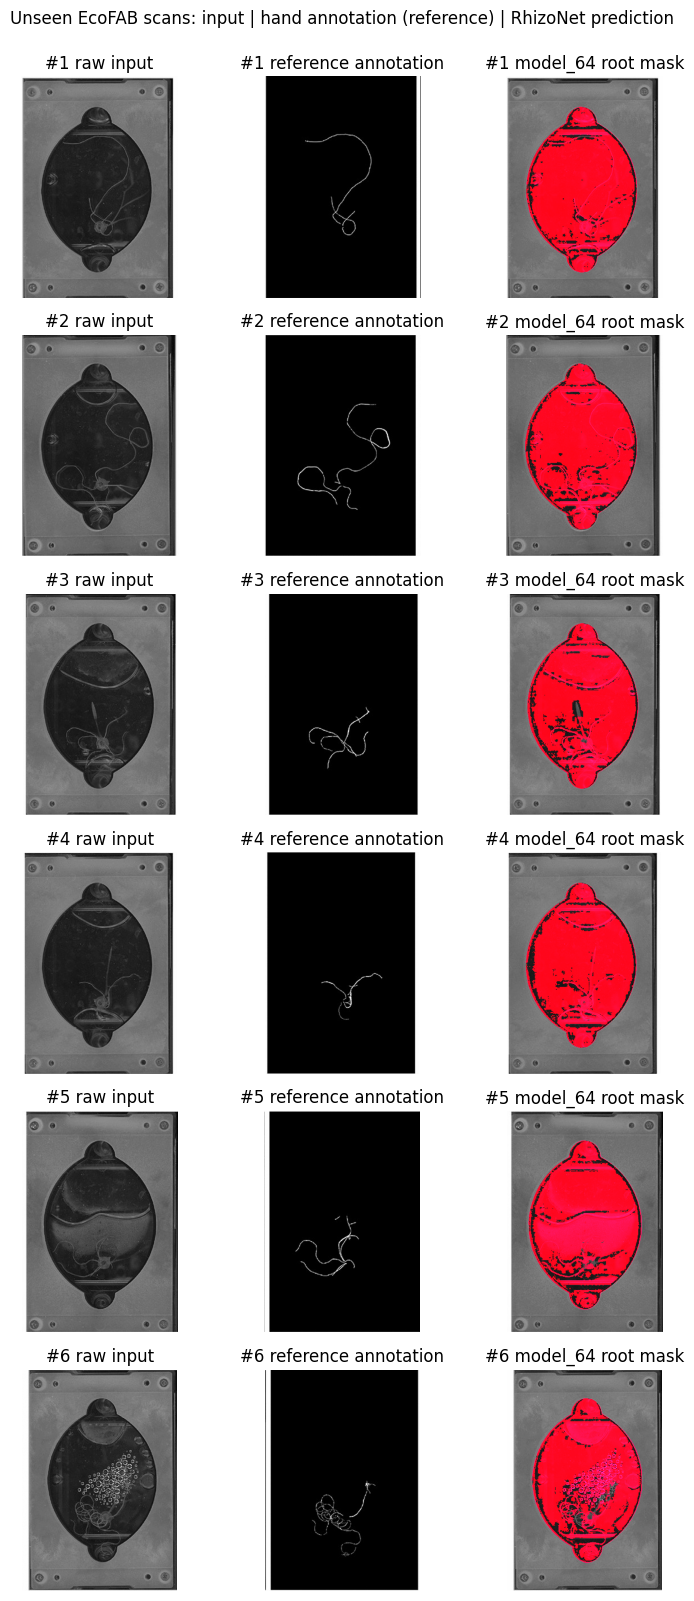

In [ ]:
fig, axes = plt.subplots(6, 3, figsize=(8, 16))
for i, (im, ann) in enumerate(zip(raws, annots)):
    mask_small = np.asarray(Image.fromarray(binary_masks[i]).resize(raws[i].size, Image.NEAREST))
    a = np.asarray(im.convert("L"))
    axes[i, 0].imshow(a, cmap="gray"); axes[i, 0].set_title(f"#{i+1} raw input")
    axes[i, 1].imshow(np.asarray(ann.convert("L")), cmap="gray"); axes[i, 1].set_title(f"#{i+1} reference annotation")
    rgb = np.stack([a]*3, axis=-1).astype(float)
    overlay = rgb.copy(); overlay[..., 0][mask_small > 0] = 255; overlay[..., 1][mask_small > 0] *= 0.25
    axes[i, 2].imshow(overlay.astype(np.uint8)); axes[i, 2].set_title(f"#{i+1} model_64 root mask")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Unseen EcoFAB scans: input | hand annotation (reference) | RhizoNet prediction", y=0.998)
fig.tight_layout()
fig.savefig(BASE / "comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## 15. Convexification post-processing (author `rhizonet.postprocessing.processing`)

The paper's pipeline adds a convex-hull "convexification" step: morphological dilation of the
prediction, largest connected component, `convex_hull_image`, area closing/opening and a final
erosion with a 2-px disk — with parameters taken from the authors' `setup-processing.json`.
The authors' function is called on the prediction directory exactly as their
`postprocess_rhizonet` CLI would. (This operates on scan-scale 2039×3000 masks and can take a
couple of minutes on CPU.)

**日本語:** 論文の後処理（凸包化＋モルフォロジー演算）を、著者の `processing()` を
`setup-processing.json` のパラメータでそのまま実行します（スキャン解像度のため CPU で数分の
場合があります）。

In [ ]:
pcfg = json.loads((BASE / "setup_files" / "setup-processing.json").read_text())
print("processing config:", {k: pcfg[k] for k in ["area_closing", "area_opening", "disk_radius"]})

from rhizonet.postprocessing import processing

proc_dir = BASE / "processed"
processing(str(pred_dir), str(proc_dir),
           area_opening_param=pcfg["area_opening"],
           area_closing_param=pcfg["area_closing"],
           disk_radius=pcfg["disk_radius"])
print("processed files:", sorted(p.name for p in proc_dir.iterdir()))

processing config: {'area_closing': 200, 'area_opening': 500, 'disk_radius': 4}


  0%|          | 0/6 [00:00<?, ?it/s]

Processing scan_1.png


 17%|█▋        | 1/6 [00:58<04:53, 58.61s/it]

Processing scan_2.png


...

 83%|████████▎ | 5/6 [04:51<00:58, 58.45s/it]

Processing scan_6.png


100%|██████████| 6/6 [05:49<00:00, 58.25s/it]

100%|██████████| 6/6 [05:49<00:00, 58.23s/it]

processed files: ['scan_1.png', 'scan_2.png', 'scan_3.png', 'scan_4.png', 'scan_5.png', 'scan_6.png']


## 16. Raw vs post-processed predictions and biomass table

**AI-generated display cell.** Shows the convexified masks and tabulates biomass before/after
post-processing (author `get_biomass`, scan-scale pixels). Exported as CSV.

**日本語:** 凸包化後のマスクを表示し、後処理前後のバイオマス（根画素数）を表と CSV で示します。

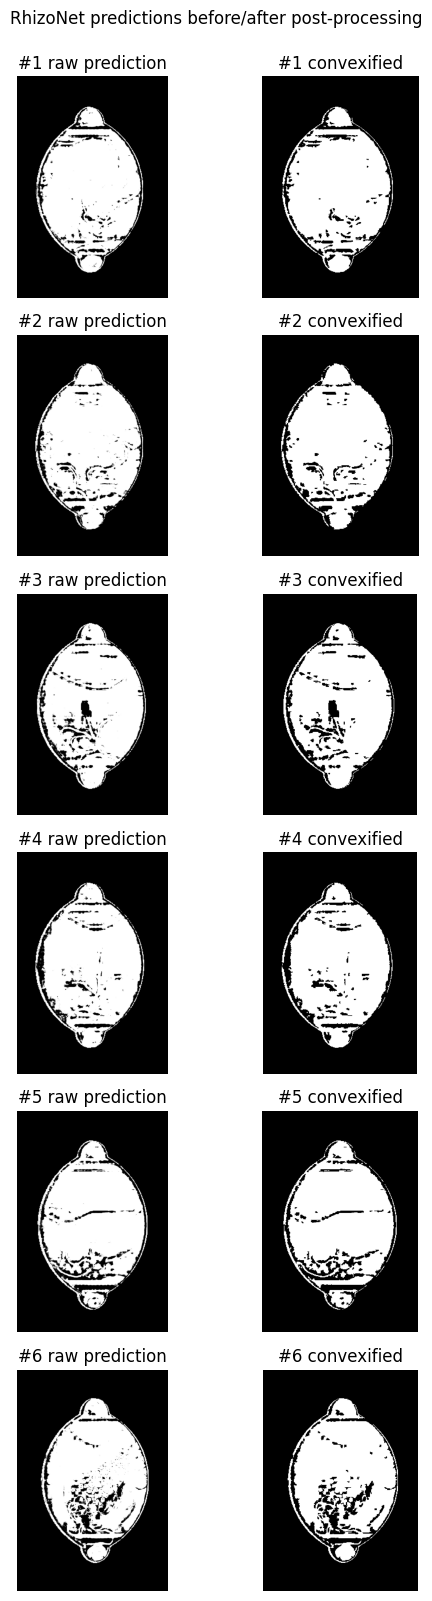

   scan  biomass_raw_px  biomass_processed_px
scan_#1         1958085               1898235
scan_#2         1969391               1903236
scan_#3         1940357               1869323
scan_#4         1943503               1877621
scan_#5         1954722               1876155
scan_#6         1837681               1760732


In [ ]:
proc_masks = {i: io.imread(str(proc_dir / f"scan_{i+1}.png")) for i in range(6)}

fig, axes = plt.subplots(6, 2, figsize=(6, 16))
for i in range(6):
    proc_small = np.asarray(Image.fromarray(proc_masks[i]).resize(raws[i].size, Image.NEAREST))
    axes[i, 0].imshow(binary_masks[i] > 0, cmap="gray"); axes[i, 0].set_title(f"#{i+1} raw prediction")
    axes[i, 1].imshow(proc_small, cmap="gray"); axes[i, 1].set_title(f"#{i+1} convexified")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("RhizoNet predictions before/after post-processing", y=0.998)
fig.tight_layout()
fig.savefig(BASE / "postprocessed.png", dpi=110, bbox_inches="tight")
plt.show()

biomass_df = pd.DataFrame([{"scan": f"scan_#{i+1}",
                            "biomass_raw_px": biomass_raw[i],
                            "biomass_processed_px": int(get_biomass(proc_masks[i]))} for i in range(6)])
print(biomass_df.to_string(index=False))
biomass_df.to_csv(BASE / "biomass.csv", index=False)

## 17. Agreement with the paper's annotations and with its published patch-64 predictions

**AI-generated evaluation cell.** Two comparisons, both at scan scale: (a) against the paper's
hand annotations (Fig 3, column 2); (b) against the patch-64 prediction panels published in
Figure 3 column 3 — a direct reproduction check. Both reference panels are JPEG-smeared
grayscale renderings of binary masks (no saturated colors; decaying histograms), so their
foreground is recovered with a mid-gray threshold; the fraction table printed below the metrics
makes the comparison context explicit. These scores are an *additional evaluation created for
this notebook*; paper Table 2 uses the authors' exact metric code on the original scans.

**日本語:** スキャン スケールで 2 つの比較を行います：(a) 手動アノテーションとの一致
(IoU/Dice)、(b) Fig. 3 第 3 列に公開された patch-64 予測パネルとの一致（再現性の直接確認）。
参照パネルは JPEG 圧縮でにじんだ白黒マスクのため、中間Grayしきい値で前景を復元します。
結果は CSV にも保存します。

In [ ]:
def iou_dice(pred_fg, ref_fg):
    inter = np.logical_and(pred_fg, ref_fg).sum()
    union = np.logical_or(pred_fg, ref_fg).sum()
    iou = inter / union if union else float("nan")
    dice = 2 * inter / (pred_fg.sum() + ref_fg.sum()) if (pred_fg.sum() + ref_fg.sum()) else float("nan")
    return iou, dice

# The published panels are JPEG-smeared grayscale renderings of the binary masks
# (probe: no saturated colors, decaying histogram), so the foreground is recovered
# with a mid-gray threshold instead of an exact ==255 test.
rows = []
for i in range(6):
    ref = np.asarray(annots_full[i].convert("L"))
    ref_fg = ref > 127
    pub_fg = np.asarray(pub64_full[i].convert("L")) > 127
    iou_r, dice_r = iou_dice(binary_masks[i] > 0, ref_fg)
    iou_p, dice_p = iou_dice(proc_masks[i] > 0, ref_fg)
    iou_pub, dice_pub = iou_dice(binary_masks[i] > 0, pub_fg)
    iou_pub_p, dice_pub_p = iou_dice(proc_masks[i] > 0, pub_fg)
    rows.append({"scan": f"scan_#{i+1}",
                 "iou_vs_annotation": round(float(iou_r), 4), "dice_vs_annotation": round(float(dice_r), 4),
                 "iou_processed_vs_annotation": round(float(iou_p), 4), "dice_processed_vs_annotation": round(float(dice_p), 4),
                 "iou_vs_published_pred64": round(float(iou_pub), 4),
                 "dice_vs_published_pred64": round(float(dice_pub), 4)})
metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))
print("\nforeground fractions (scan scale): predicted",
      round(float(np.mean([(binary_masks[i] > 0).mean() for i in range(6)])), 3),
      "| published pred64", round(float(np.mean([(np.asarray(p.convert('L')) > 127).mean() for p in pub64_full])), 3),
      "| annotation", round(float(np.mean([(np.asarray(a.convert('L')) > 127).mean() for a in annots_full])), 3))
metrics_df.to_csv(BASE / "metrics_vs_references.csv", index=False)

   scan  iou_vs_annotation  dice_vs_annotation  iou_processed_vs_annotation  dice_processed_vs_annotation  iou_vs_published_pred64  dice_vs_published_pred64
scan_#1             0.0086              0.0171                       0.0085                        0.0169                   0.0229                    0.0447
scan_#2             0.0136              0.0269                       0.0134                        0.0264                   0.0346                    0.0668
scan_#3             0.0111              0.0220                       0.0114                        0.0225                   0.0226                    0.0442
scan_#4             0.0062              0.0123                       0.0064                        0.0126                   0.0184                    0.0361
scan_#5             0.0096              0.0190                       0.0092                        0.0182                   0.0235                    0.0459
scan_#6             0.0045              0.0089            

## 18. Input-fidelity check: why quantitative agreement is not achievable here

**Measured diagnostic (AI-generated glue, two extra inference passes on scan #1).** The released
model was trained on sharp 600-dpi scans; the only public form of this paper's scans is the
~7.5×-downsampled JPEG figure, which cannot restore that sharpness. The cell quantifies the
consequence on scan #1: with the author pipeline the prediction covers a much larger fraction of
the scan than the paper's published patch-64 mask of the *same* image, and without the author's
largest-connected-component mask the model marks almost the whole blurred scan as root. The
pipeline mechanics are exactly the authors'; the inputs are not the authors' bytes.

**日本語:** 公開されているのは約 7.5 倍縮小の JPEG 図版のみで、元の 600 dpi スキャンは公開されて
いません。scan #1 での実測：著者パイプラインの予測は論文公開マスクより大きく、LCC マスクなしでは
ほぼ全画面が根と予測されます。パイプライン自体は著者のままであり、入力の忠実度が定量比較の
限界です。

In [ ]:
p = in_dir / "scan_1.png"
image, _ = transform_image(str(p))                     # panel scale, as in the author pipeline
im_up = raws[0].resize((SCAN_W, SCAN_H), Image.LANCZOS)
cB = np.transpose(np.asarray(im_up).astype(np.float32) / 255.0, (2, 0, 1))[None]
tB = torch.tensor(cB).to(device)
with torch.inference_mode():
    logitsB = pred_function(tB.float(), unet, pred_patch_size)
mappedB = MapImage(torch.argmax(logitsB, dim=1).byte(), pred_labels, reverse=True)
no_lcc_fg = (mappedB.cpu().numpy().squeeze() == root_value)

pub1 = np.asarray(pub64_full[0].convert("L")) > 127
ann1 = np.asarray(annots_full[0].convert("L")) > 127
print("scan #1 foreground fractions at scan scale:")
print("  our prediction (author pipeline, with LCC):", round(float((binary_masks[0] > 0).mean()), 3))
print("  our prediction without the LCC mask       :", round(float(no_lcc_fg.mean()), 3))
print("  published patch-64 mask (Fig 3, column 3) :", round(float(pub1.mean()), 3))
print("  hand-annotated root mask (Fig 3, column 2):", round(float(ann1.mean()), 3))

/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:225: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/usr/local/lib/python3.13/dist-packages/monai/inferers/utils.py:360: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


scan #1 foreground fractions at scan scale:
  our prediction (author pipeline, with LCC): 0.32
  our prediction without the LCC mask       : 0.95
  published patch-64 mask (Fig 3, column 3) : 0.051
  hand-annotated root mask (Fig 3, column 2): 0.04


## 18. Interpretation, scope and validation record

**What was executed here:** the EcoBOT paper's image-analysis step — RhizoNet (Residual U-Net on
64×64 sliding-window patches) root segmentation of EcoFAB scans, convexification post-processing,
and biomass as root-pixel count — using the authors' pinned code (`lbl-camera/rhizonet` @
`41e1b31d`) and released `model_64` weights, on six real unseen EcoFAB scans taken from
RhizoNet Figure 3 (CC BY 4.0), restored to the paper's 2039×3000 scan scale, with agreement
measured against the paper's hand annotations and its published patch-64 prediction panels.

**Documented adaptations:** (1) preinstalled PyTorch + checkpoint-loading adapter (section 5);
(2) root-class selection by annotation agreement because the released config's `frg_class: 255`
is inconsistent with its own `labels` (section 12); (3) figure-derived inputs resampled to scan
scale (section 10) because the tutorial's original input files are not public and the panels are
downsampled renderings. No scientific parameter was invented; thresholds come from the authors'
config and code.

**What this does NOT show:** EcoBOT hardware/control, the paper's own 1,633 scans, hyperspectral
EcoSpec analysis, GP/BO modelling, the EcoBOT-specific fine-tuned checkpoints (not public), and
dataset-level accuracy of either paper.

**Measured input-fidelity limitation (section 18):** the original 600-dpi scans are not public;
the only public form is the ~7.5×-downsampled JPEG figure. On those inputs the released model
over-segments relative to the paper's own published patch-64 masks of the same images (measured
in section 18) — so the IoU/Dice scores here validate the *pipeline*, not the paper's accuracy.
A faithful quantitative reproduction requires the original scans, which the data statements do
not deposit. The author tutorial's ground-truth scale-weight comparison is not possible
publicly either.

**References:** Sordo et al. 2025 (EcoBOT, Front. Plant Sci. 16:1633557); Sordo et al. 2024
(RhizoNet, Sci. Rep. 14:12907); author code `lbl-camera/rhizonet` (MIT) commits `41e1b31d`
(code/config) and `b959c351` (model weights). Config values were read from the authors'
`setup_files` at runtime rather than invented.

**検証記録（日本語）:** 本ノートブックは Colab 上で上から下まで一括実行され、全セルの実行出力が
保存されています。使用したランタイム（CPU または GPU）と実行日は、下の出力およびレポートを参照して
ください。EcoBOT の画像解析工程（RhizoNet による根セグメンテーション・後処理・バイオマス集計）を
著者コード・公開重み・実スキャンで部分再現しました。

In [ ]:
import datetime
print("validation record:", datetime.datetime.now(datetime.timezone.utc).isoformat())
print("executed device:", "CPU" if device.type == "cpu" else "GPU")
print("torch", torch.__version__, "| pytorch_lightning", pl.__version__, "| monai", monai.__version__)
print("checkpoint:", ckpt_path.name, len(data), "bytes, git blob", blob_sha1)
print("sample: 6 unseen EcoFAB scans, RhizoNet Fig. 3 col 1 (scan scale 2039x3000);")
print("references: col 2 hand annotations, col 3 published patch-64 predictions")

validation record: 2026-10-07T07:34:29.049042+00:00
executed device: GPU
torch 2.11.0+cu130 | pytorch_lightning 2.0.9.post0 | monai 1.3.2
checkpoint: model_64.ckpt 38398421 bytes, git blob 456f2f90781fbfe96c8321755168adcedc282ea5
sample: 6 unseen EcoFAB scans, RhizoNet Fig. 3 col 1 (scan scale 2039x3000);
references: col 2 hand annotations, col 3 published patch-64 predictions
